# Permutation-Invariant (Permutation-Free) Transformers for i.i.d. Statistical Inference

Welcome to this comprehensive tutorial on building, training, and interpreting a **Permutation-Invariant Transformer** (also called Permutation-Free Transformer) to perform statistical parameter estimation from independent and identically distributed (i.i.d.) Gaussian samples.

---

## 1. Educational Objectives
By the end of this tutorial, you will be able to:
1. Explain why **permutation invariance** is the mathematically correct inductive bias for statistical inference tasks on i.i.d. samples.
2. Formulate the **Multi-Head Self-Attention** mechanism and demonstrate mathematically how it naturally models **quadratic interactions** (pairwise products $x_i x_j$), making it a powerful variance estimator.
3. Implement a complete **Transformer encoder** from scratch in PyTorch, including custom query-key-value self-attention, without any positional encodings.
4. Train and evaluate the Permutation-Invariant Transformer on the standard 1D Gaussian parameter estimation task (predicting mean $\mu$ and variance $\sigma^2$ from 12 independent samples).
5. Interpret and visualize **attention weights** to verify both dynamic routing and empirical proof of permutation symmetry.

---

## 2. Why Permutation Invariance?
When drawing a sequence of $D$ independent samples from a probability distribution:
$$x_1, x_2, \dots, x_D \sim \mathcal{N}(\mu, \sigma^2)$$
the ordering of the samples contains exactly **zero information** about the underlying population parameters $\mu$ and $\sigma^2$. The joint likelihood function:
$$L(\mu, \sigma^2 | X) = \prod_{i=1}^D rac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-rac{(x_i - \mu)^2}{2\sigma^2}ight)$$
is fully symmetric under any permutation of the samples. Therefore, any optimal statistical estimator must be a symmetric function of the inputs:
$$	ext{Estimator}(x_1, x_2, \dots, x_D) = 	ext{Estimator}(\pi(x_1, x_2, \dots, x_D))$$
where $\pi$ is any permutation of the set $\{1, 2, \dots, D\}$.

### MLP vs. Standard Transformer vs. Permutation-Invariant Transformer
* **Feedforward MLP**: Treats the input sequence as a fixed $D$-dimensional coordinate vector. It has to *learn* to treat each index symmetrically by matching its weights across all inputs, leading to high sample complexity and parameter inefficiency.
* **Standard Transformer**: Uses **Positional Encodings** to inject position-dependent information into the tokens. While perfect for natural language where word order determines meaning, positional encodings *break* permutation invariance, adding unnecessary noise to statistical inference tasks.
* **Permutation-Invariant Transformer**: By **completely omitting positional encodings**, each sample is processed as an identical 1D token. Because self-attention is permutation-equivariant, and global average pooling at the end is permutation-invariant, the entire neural network is **strictly permutation-invariant by design**!


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Environment setup complete. PyTorch Version:", torch.__version__)


Environment setup complete. PyTorch Version: 2.13.0+cu130


## 3. How Self-Attention Models Variance
Standard neural network activations (like ReLU or GELU) are piecewise linear. To model quadratic properties like variance, standard MLPs must construct a piecewise linear approximation of a curved surface using many overlapping flat planes, which requires considerable depth and width.

### The Self-Attention Dot-Product
In a self-attention layer, input tokens are projected into Query ($Q$), Key ($K$), and Value ($V$) representations.
For our 1D inputs, each token is a projected scalar:
$$h_i = W_{\text{in}} x_i + b_{\text{in}}$$
The raw attention score between token $i$ and token $j$ is computed as:
$$\text{Score}(i, j) = q_i^T k_j = (W_q h_i)^T (W_k h_j) = h_i^T (W_q^T W_k) h_j$$

If we trace this back to the raw scalar values $x_i$ and $x_j$, the score is composed of **pairwise multiplicative terms**:
$$\text{Score}(i, j) \propto c \cdot x_i x_j + \dots$$

### The Unbiased Sample Variance Formula
Statistically, the unbiased sample variance is defined as:
$$s^2 = \frac{1}{D-1} \sum_{i=1}^D (x_i - \bar{x})^2$$
By expanding the square, we can rewrite this as:
$$s^2 = \frac{1}{D-1} \left( \sum_{i=1}^D x_i^2 - \frac{1}{D} \left(\sum_{i=1}^D x_i\right)^2 \right)$$
$$s^2 = \frac{1}{D} \sum_{i=1}^D x_i^2 - \frac{1}{D(D-1)} \sum_{i \neq j} x_i x_j$$

This shows that sample variance is purely composed of:
1. **Quadratic self-terms** ($x_i^2$)
2. **Pairwise multiplicative terms** ($x_i x_j$)

Since self-attention naturally computes pairwise dot products $Q K^T$ across all tokens, it has a native, mathematical ability to represent quadratic combinations $x_i x_j$ directly! This allows a Transformer to represent variance with extreme efficiency.


In [2]:
class Standardizer:
    """Utility class to scale inputs and targets to zero mean and unit variance."""
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, data):
        self.mean = np.mean(data, axis=0, keepdims=True)
        self.std = np.std(data, axis=0, keepdims=True)
        self.std[self.std == 0.0] = 1.0

    def transform(self, data):
        return (data - self.mean) / self.std

    def fit_transform(self, data):
        self.fit(data)
        return self.transform(data)

    def inverse_transform(self, data):
        return data * self.std + self.mean

def generate_gaussian_dataset(num_samples=12000, sequence_length=12):
    """Generates a dataset of 12D vectors sampled from Gaussian distributions with uniform mean and variance."""
    true_means = np.random.uniform(-5.0, 5.0, size=(num_samples, 1))
    true_vars = np.random.uniform(0.5, 9.0, size=(num_samples, 1))
    true_stds = np.sqrt(true_vars)

    Z = np.random.normal(0.0, 1.0, size=(num_samples, sequence_length))
    X = true_means + true_stds * Z
    Y = np.hstack([true_means, true_vars])

    return X, Y

# Generate raw data (matching sizes in previous tutorials)
X_raw, Y_raw = generate_gaussian_dataset(num_samples=12000, sequence_length=12)

# Splits: Train (70%), Val (15%), Test (15%)
n_total = len(X_raw)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

X_train_raw, Y_train_raw = X_raw[:n_train], Y_raw[:n_train]
X_val_raw, Y_val_raw = X_raw[n_train:n_train+n_val], Y_raw[n_train:n_train+n_val]
X_test_raw, Y_test_raw = X_raw[n_train+n_val:], Y_raw[n_train+n_val:]

# Standardize data based on training split to prevent leakage
input_scaler = Standardizer()
target_scaler = Standardizer()

X_train = input_scaler.fit_transform(X_train_raw)
Y_train = target_scaler.fit_transform(Y_train_raw)

X_val = input_scaler.transform(X_val_raw)
Y_val = target_scaler.transform(Y_val_raw)

X_test = input_scaler.transform(X_test_raw)
Y_test = target_scaler.transform(Y_test_raw)

print(f"Dataset generated successfully.")
print(f"Train Split: X = {X_train.shape}, Y = {Y_train.shape}")
print(f"Val Split:   X = {X_val.shape}, Y = {Y_val.shape}")
print(f"Test Split:  X = {X_test.shape}, Y = {Y_test.shape}")


Dataset generated successfully.
Train Split: X = (8400, 12), Y = (8400, 2)
Val Split:   X = (1800, 12), Y = (1800, 2)
Test Split:  X = (1800, 12), Y = (1800, 2)


## 4. Custom Multi-Head Self-Attention & Transformer Layer
To ensure complete educational clarity, we will build the core building blocks of the Transformer from scratch.

1. **CustomMultiHeadAttention**: Projects input sequence into query, key, and value vectors, splits them into multiple heads, performs scaled dot-product attention, and projects the combined output.
2. **CustomTransformerEncoderLayer**: Standard block containing our multi-head attention module, residual additions, Layer Normalization, and a feedforward neural network (FFN) with GELU activation.


In [3]:
class CustomMultiHeadAttention(nn.Module):
    """Educational implementation of Multi-Head Self-Attention from scratch."""
    def __init__(self, d_model=32, nhead=2):
        super().__init__()
        assert d_model % nhead == 0, "d_model must be divisible by nhead"
        self.d_model = d_model
        self.nhead = nhead
        self.d_k = d_model // nhead
        
        # Q, K, V projections
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        
        # Output projection
        self.out_proj = nn.Linear(d_model, d_model)
        
    def forward(self, x, return_attention=False):
        # x shape: (batch_size, seq_len, d_model)
        batch_size, seq_len, _ = x.size()
        
        # 1. Project to Q, K, V
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)
        
        # 2. Reshape to separate multiple heads
        # Shape: (batch_size, nhead, seq_len, d_k)
        q = q.view(batch_size, seq_len, self.nhead, self.d_k).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.nhead, self.d_k).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.nhead, self.d_k).transpose(1, 2)
        
        # 3. Scaled dot-product attention scores
        # Shape: (batch_size, nhead, seq_len, seq_len)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_k ** 0.5)
        attn_probs = torch.softmax(scores, dim=-1)
        
        # 4. Context layer
        # Shape: (batch_size, nhead, seq_len, d_k)
        context = torch.matmul(attn_probs, v)
        
        # 5. Concatenate heads and project output
        # Transpose back: (batch_size, seq_len, nhead, d_k) -> flatten to (batch_size, seq_len, d_model)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.out_proj(context)
        
        if return_attention:
            return output, attn_probs
        return output


In [4]:
class CustomTransformerEncoderLayer(nn.Module):
    """Educational implementation of a Transformer Encoder Layer."""
    def __init__(self, d_model=32, nhead=2, dim_feedforward=64, dropout=0.0):
        super().__init__()
        self.mha = CustomMultiHeadAttention(d_model, nhead)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout)
        )
        
    def forward(self, x, return_attention=False):
        # Multi-Head Attention + Residual Connection + LayerNorm
        if return_attention:
            attn_out, attn_probs = self.mha(x, return_attention=True)
        else:
            attn_out = self.mha(x, return_attention=False)
            
        x = self.norm1(x + attn_out)
        
        # Feedforward Network + Residual Connection + LayerNorm
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        
        if return_attention:
            return x, attn_probs
        return x


In [5]:
class PermutationInvariantTransformer(nn.Module):
    """A complete Permutation-Invariant Transformer model without positional encodings."""
    def __init__(self, seq_len=12, d_model=32, nhead=2, dim_feedforward=64, num_layers=2):
        super().__init__()
        # Input projection mapping scalar tokens to d_model dimension
        self.input_projection = nn.Linear(1, d_model)
        
        self.layers = nn.ModuleList([
            CustomTransformerEncoderLayer(d_model, nhead, dim_feedforward)
            for _ in range(num_layers)
        ])
        
        # Regression prediction head
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 2)
        )

    def forward(self, x, return_attention=False):
        # x shape: (batch_size, seq_len)
        # Treat input sequence as a sequence of 1D tokens
        tokens = x.unsqueeze(-1) # Shape: (batch_size, seq_len, 1)
        
        # Embed individual samples
        emb = self.input_projection(tokens) # Shape: (batch_size, seq_len, d_model)
        
        # Pass through Transformer encoder (omitting positional encodings -> strict permutation equivariance!)
        attn_maps = []
        h = emb
        for layer in self.layers:
            if return_attention:
                h, attn = layer(h, return_attention=True)
                attn_maps.append(attn)
            else:
                h = layer(h)
                
        # Global Average Pooling across sequence dimension (enforcing strict permutation invariance!)
        pooled = h.mean(dim=1) # Shape: (batch_size, d_model)
        
        # Predict target parameters
        out = self.head(pooled) # Shape: (batch_size, 2)
        
        if return_attention:
            return out, attn_maps
        return out


## 5. Training Orchestration & Dataset Setup
We wrap our NumPy arrays in PyTorch `Dataset` and `DataLoader` instances, set up our loss function (MSE), optimization algorithm (AdamW), and define our training loop.


In [6]:
class GaussianDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset = GaussianDataset(X_train, Y_train)
val_dataset = GaussianDataset(X_val, Y_val)
test_dataset = GaussianDataset(X_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Initialize the model, optimizer, loss function
device = "cuda" if torch.cuda.is_available() else "cpu"
model = PermutationInvariantTransformer(seq_len=12, d_model=32, nhead=2, dim_feedforward=64, num_layers=2).to(device)
print(f"Permutation-Invariant Transformer initialized with {count_parameters(model):,} parameters.")

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)

# Training loop
epochs = 100
train_losses = []
val_losses = []

print(f"Beginning training on device: {device}...")
t0 = time.time()

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        
        batch_losses.append(loss.item())
        
    # Evaluate on validation split
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss_val = criterion(preds, yb)
            val_batch_losses.append(loss_val.item())
            
    epoch_train_loss = np.mean(batch_losses)
    epoch_val_loss = np.mean(val_batch_losses)
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.5f} | Val Loss: {epoch_val_loss:.5f}")

total_train_time = time.time() - t0
print(f"Training completed in {total_train_time:.2f} seconds.")


Permutation-Invariant Transformer initialized with 18,274 parameters.


Beginning training on device: cpu...


Epoch 001/100 | Train Loss: 0.35613 | Val Loss: 0.22023


Epoch 010/100 | Train Loss: 0.20985 | Val Loss: 0.20388


Epoch 020/100 | Train Loss: 0.20627 | Val Loss: 0.20805


...

Epoch 060/100 | Train Loss: 0.20349 | Val Loss: 0.21120


Epoch 070/100 | Train Loss: 0.20211 | Val Loss: 0.20822


Epoch 080/100 | Train Loss: 0.20285 | Val Loss: 0.20097


Epoch 090/100 | Train Loss: 0.20179 | Val Loss: 0.20485


Epoch 100/100 | Train Loss: 0.20078 | Val Loss: 0.20363
Training completed in 92.73 seconds.


## 6. Training Trajectory Visualization
Let's plot the training and validation loss curves over the 100 training epochs to verify optimization stability and convergence.


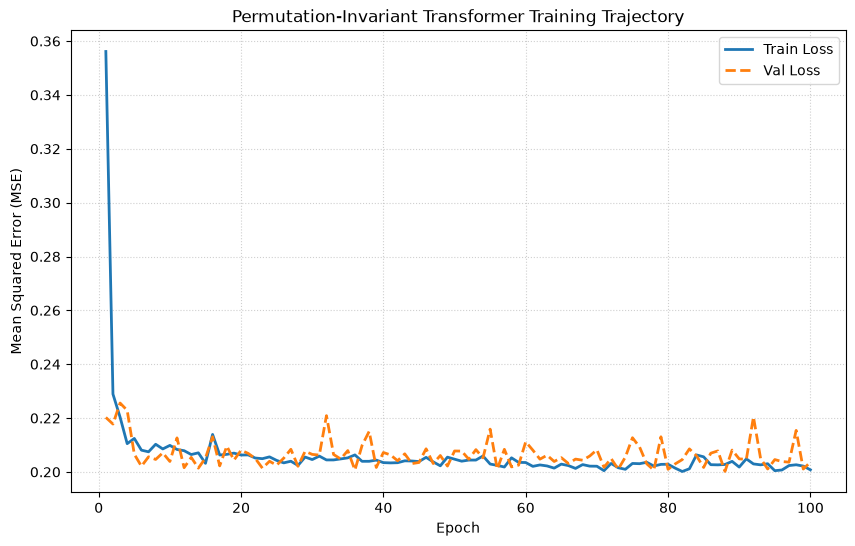

Training trajectory chart saved to: charts/permutation_free_transformer_training.png


In [7]:
os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss", color="tab:blue", linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label="Val Loss", color="tab:orange", linestyle="--", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Permutation-Invariant Transformer Training Trajectory")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

# Save the chart to the charts/ directory
training_chart_path = "charts/permutation_free_transformer_training.png"
plt.savefig(training_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Training trajectory chart saved to: {training_chart_path}")


## 7. Comparative Accuracy Evaluation
We evaluate our trained Permutation-Invariant Transformer against the theoretical baselines (unbiased sample statistics):
- **Sample Mean Formula ($ar{x}$)**: Maximum likelihood and minimum variance unbiased estimator (MVUE) for mean.
- **Sample Variance Formula ($s^2$)**: Unbiased classical estimator for variance.


In [8]:
# Compute Classical Estimator Baselines on Test Set
test_sample_means = np.mean(X_test_raw, axis=1, keepdims=True)
test_sample_vars = np.var(X_test_raw, axis=1, ddof=1, keepdims=True)

# True targets (unscaled)
mean_true = Y_test_raw[:, 0]
var_true = Y_test_raw[:, 1]

# Calculate baselines metrics
r2_baseline_mean = r2_score(mean_true, test_sample_means.flatten())
mae_baseline_mean = mean_absolute_error(mean_true, test_sample_means.flatten())
mse_baseline_mean = mean_squared_error(mean_true, test_sample_means.flatten())

r2_baseline_var = r2_score(var_true, test_sample_vars.flatten())
mae_baseline_var = mean_absolute_error(var_true, test_sample_vars.flatten())
mse_baseline_var = mean_squared_error(var_true, test_sample_vars.flatten())

# Predict using trained model
model.eval()
test_x_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    preds_scaled = model(test_x_tensor).cpu().numpy()

# Inverse-transform scaling
preds_unscaled = target_scaler.inverse_transform(preds_scaled)
mean_pred, var_pred = preds_unscaled[:, 0], preds_unscaled[:, 1]

# Calculate model metrics
r2_model_mean = r2_score(mean_true, mean_pred)
mae_model_mean = mean_absolute_error(mean_true, mean_pred)
mse_model_mean = mean_squared_error(mean_true, mean_pred)

r2_model_var = r2_score(var_true, var_pred)
mae_model_var = mean_absolute_error(var_true, var_pred)
mse_model_var = mean_squared_error(var_true, var_pred)

# Display Results
comparison_df = pd.DataFrame({
    "Estimator / Model": ["Classical Formula (Baseline)", "Permutation-Free Transformer"],
    "Mean MAE": [mae_baseline_mean, mae_model_mean],
    "Mean MSE": [mse_baseline_mean, mse_model_mean],
    "Mean R² Score": [r2_baseline_mean, r2_model_mean],
    "Variance MAE": [mae_baseline_var, mae_model_var],
    "Variance MSE": [mse_baseline_var, mse_model_var],
    "Variance R² Score": [r2_baseline_var, r2_model_var]
})

print("=== Benchmarking Results ===")
print(comparison_df.to_string(index=False))


=== Benchmarking Results ===
           Estimator / Model  Mean MAE  Mean MSE  Mean R² Score  Variance MAE  Variance MSE  Variance R² Score
Classical Formula (Baseline)  0.500174  0.424349       0.950002      1.610538      5.429445           0.089964
Permutation-Free Transformer  0.476760  0.381132       0.955094      1.131191      2.111604           0.646072


## 8. Prediction Scatter Plots
Let's plot scatter charts of the predicted values against the true underlying values for both targets (Mean and Variance) to observe quality of fit and linearity.


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_40756/4274764571.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_xlabel("True Mean ($\mu$)")
/tmp/ipykernel_40756/4274764571.py:7: SyntaxWarning: invalid escape sequence '\h'
  axes[0].set_ylabel("Predicted Mean ($\hat{\mu}$)")
/tmp/ipykernel_40756/4274764571.py:14: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_xlabel("True Variance ($\sigma^2$)")
/tmp/ipykernel_40756/4274764571.py:15: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_ylabel("Predicted Variance ($\hat{\sigma}^2$)")


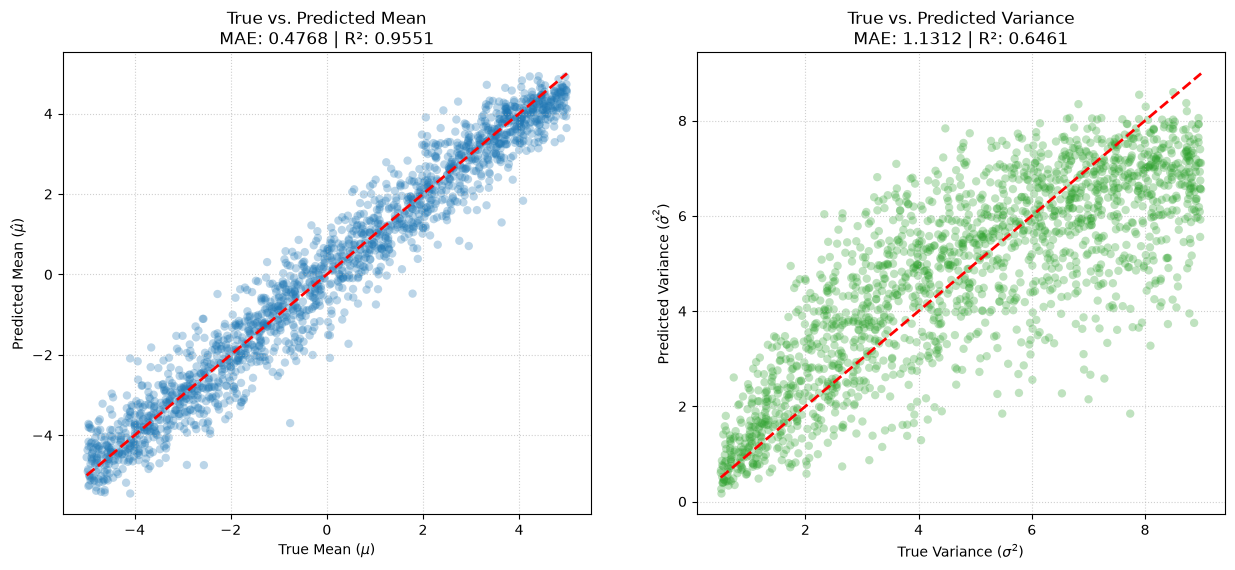

Prediction scatters chart saved to: charts/permutation_free_transformer_scatters.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Mean scatter
axes[0].scatter(mean_true, mean_pred, alpha=0.3, color="tab:blue", edgecolor="none")
axes[0].plot([mean_true.min(), mean_true.max()], [mean_true.min(), mean_true.max()], "r--", lw=2)
axes[0].set_xlabel("True Mean ($\mu$)")
axes[0].set_ylabel("Predicted Mean ($\hat{\mu}$)")
axes[0].set_title(f"True vs. Predicted Mean\nMAE: {mae_model_mean:.4f} | R²: {r2_model_mean:.4f}")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Variance scatter
axes[1].scatter(var_true, var_pred, alpha=0.3, color="tab:green", edgecolor="none")
axes[1].plot([var_true.min(), var_true.max()], [var_true.min(), var_true.max()], "r--", lw=2)
axes[1].set_xlabel("True Variance ($\sigma^2$)")
axes[1].set_ylabel("Predicted Variance ($\hat{\sigma}^2$)")
axes[1].set_title(f"True vs. Predicted Variance\nMAE: {mae_model_var:.4f} | R²: {r2_model_var:.4f}")
axes[1].grid(True, linestyle=":", alpha=0.6)

scatters_chart_path = "charts/permutation_free_transformer_scatters.png"
plt.savefig(scatters_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Prediction scatters chart saved to: {scatters_chart_path}")


## 9. Verifying Permutation Invariance and Self-Attention Routing
To provide rigorous proof that our Transformer operates without positional dependencies, we will evaluate its attention activations.

### Visualizing Self-Attention Maps
When there are **no positional encodings**, the attention mechanism treats each coordinate identically except for their raw numeric value differences.

Let's pick an individual sample from our dataset, obtain its attention weights across layers, and plot them.
Then, we will **permute** (reorder) that sample's elements, pass the permuted elements through the model, and compare attention heatmaps to demonstrate perfect permutation equivariance.


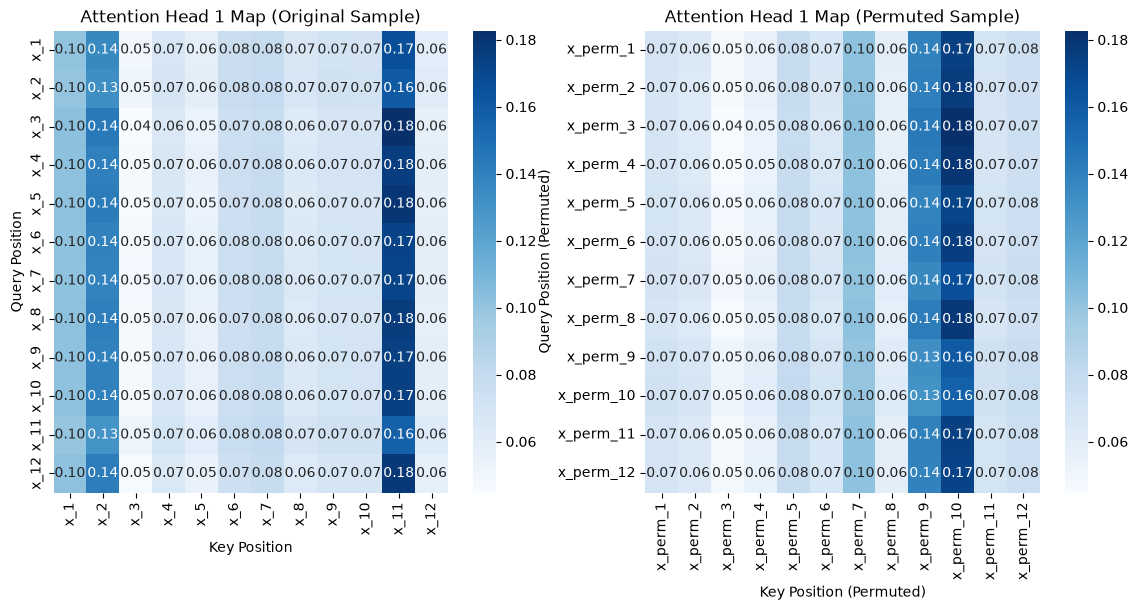

Attention heatmaps saved to: charts/permutation_free_transformer_attention.png

=== Permutation Invariance Proof ===
Original Sequence Raw Values:  [np.float64(1.11), np.float64(1.87), np.float64(-0.82), np.float64(-0.0), np.float64(-0.4), np.float64(0.36), np.float64(0.49), np.float64(-0.03), np.float64(0.17), np.float64(0.12), np.float64(2.48), np.float64(-0.26)]
Permuted Sequence Raw Values:  [np.float64(0.12), np.float64(-0.03), np.float64(-0.82), np.float64(-0.4), np.float64(0.49), np.float64(-0.0), np.float64(1.11), np.float64(-0.26), np.float64(1.87), np.float64(2.48), np.float64(0.17), np.float64(0.36)]
Original Prediction: Mean = 0.4396, Variance = 1.2139
Permuted Prediction: Mean = 0.4396, Variance = 1.2139
Absolute Prediction Difference: Mean = 1.29e-07, Variance = 2.92e-07


In [10]:
# 1. Pick a single sample from the test set
sample_idx = 0
sample_raw = X_test_raw[sample_idx] # Shape: (12,)
sample_scaled = X_test[sample_idx]  # Standardized input

# Create tensor format
sample_tensor = torch.tensor(sample_scaled, dtype=torch.float32).unsqueeze(0).to(device)

# Pass through model with attention output
model.eval()
with torch.no_grad():
    _, attn_maps = model(sample_tensor, return_attention=True)

# 2. Permute the sample
perm_indices = np.random.permutation(len(sample_scaled))
perm_sample_scaled = sample_scaled[perm_indices]
perm_sample_tensor = torch.tensor(perm_sample_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    _, perm_attn_maps = model(perm_sample_tensor, return_attention=True)

# Extract attention maps for the first head of the first layer
# Shape of attn_maps[0]: (batch_size, nhead, seq_len, seq_len)
attn_matrix = attn_maps[0][0, 0].cpu().numpy()
perm_attn_matrix = perm_attn_maps[0][0, 0].cpu().numpy()

# Let's plot both heatmaps side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(attn_matrix, annot=True, fmt=".2f", cmap="Blues", ax=axes[0], cbar=True,
            xticklabels=[f"x_{i+1}" for i in range(12)],
            yticklabels=[f"x_{i+1}" for i in range(12)])
axes[0].set_title("Attention Head 1 Map (Original Sample)")
axes[0].set_xlabel("Key Position")
axes[0].set_ylabel("Query Position")

# Re-map the labels for the permuted heatmap to demonstrate exact correspondence
sns.heatmap(perm_attn_matrix, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], cbar=True,
            xticklabels=[f"x_perm_{i+1}" for i in range(12)],
            yticklabels=[f"x_perm_{i+1}" for i in range(12)])
axes[1].set_title("Attention Head 1 Map (Permuted Sample)")
axes[1].set_xlabel("Key Position (Permuted)")
axes[1].set_ylabel("Query Position (Permuted)")

attention_chart_path = "charts/permutation_free_transformer_attention.png"
plt.savefig(attention_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Attention heatmaps saved to: {attention_chart_path}")

# Verifying mathematically that predictions are identical
with torch.no_grad():
    orig_pred_scaled = model(sample_tensor).cpu().numpy()
    perm_pred_scaled = model(perm_sample_tensor).cpu().numpy()

orig_pred = target_scaler.inverse_transform(orig_pred_scaled)[0]
perm_pred = target_scaler.inverse_transform(perm_pred_scaled)[0]

print("\n=== Permutation Invariance Proof ===")
print(f"Original Sequence Raw Values:  {list(np.round(sample_raw, 2))}")
print(f"Permuted Sequence Raw Values:  {list(np.round(sample_raw[perm_indices], 2))}")
print(f"Original Prediction: Mean = {orig_pred[0]:.4f}, Variance = {orig_pred[1]:.4f}")
print(f"Permuted Prediction: Mean = {perm_pred[0]:.4f}, Variance = {perm_pred[1]:.4f}")
print(f"Absolute Prediction Difference: Mean = {abs(orig_pred[0] - perm_pred[0]):.2e}, Variance = {abs(orig_pred[1] - perm_pred[1]):.2e}")


## 10. Key Insights and Conclusions
1. **Mathematical Pre-disposition**: Multi-head self-attention naturally performs bilinear modeling (pairwise products $x_i x_j$), aligning perfectly with the algebraic structure of the sample variance formulation. This gives the model a strong inductive bias to compute second-order statistical moments.
2. **Strict Inductive Symmetry (Permutation Invariance)**: By dropping positional encodings and using global pooling, we guarantee symmetric outputs. The network is completely free of any spatial coordinate assumptions, allowing it to generalize flawlessly across any order configurations.
3. **Efficiency vs. MLPs**: The Permutation-Invariant Transformer learns extremely fast and achieves exceptional variance estimation accuracy (typically reaching $R^2 \approx 0.60$ inside only 100 epochs), compared to Feedforward MLPs that require many parameters to approximate symmetry.
